# 02. Classical Forecasting Under a Shared Split Rule

**By the end of this notebook you should understand**
- how the codex classical study is evaluated
- which simple models hold up on the 4 anchor series
- how those models behave on a small broader benchmark


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from statsmodels.tsa.api import Holt, SimpleExpSmoothing
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA

from codex_notebooks.support import (
    CODEX_DIR,
    SERIES_KEYS,
    apply_plot_style,
    build_codex_artifacts,
    chronological_split_df,
    export_figure,
    load_artifact,
    load_study_series,
    mase,
    weighted_mae,
    weighted_rmse,
    weighted_skill,
)

warnings.filterwarnings('ignore')
apply_plot_style()
build_codex_artifacts(force=False, verbose=False)

chosen = load_artifact('chosen_manifest.parquet')
benchmark = load_artifact('benchmark_manifest.parquet')
study_series = load_study_series()
series_frames = {
    series_id: frame.sort_values('ts_index').reset_index(drop=True)
    for series_id, frame in study_series.groupby('series_id')
}

RESULTS_PATH = CODEX_DIR / 'classical_results.parquet'
FORECASTS_PATH = CODEX_DIR / 'classical_forecasts.parquet'


## 1. Model lineup

This notebook keeps the lineup teachable:
- `Naive`
- `Drift`
- `SES`
- `Holt`
- `AR(1)`
- `ARIMA(1,1,1)`


In [2]:
MODEL_META = pd.DataFrame(
    [
        {'model': 'Naive', 'family': 'baseline'},
        {'model': 'Drift', 'family': 'baseline'},
        {'model': 'SES', 'family': 'smoothing'},
        {'model': 'Holt', 'family': 'smoothing'},
        {'model': 'AR(1)', 'family': 'autoregressive'},
        {'model': 'ARIMA(1,1,1)', 'family': 'arima'},
    ]
)
MODEL_META


,model,family
0,Naive,baseline
1,Drift,baseline
2,SES,smoothing
3,Holt,smoothing
4,AR(1),autoregressive
5,"ARIMA(1,1,1)",arima


In [3]:
def forecast_classical(model_name, train_values, steps):
    train_values = np.asarray(train_values, dtype=float)
    if model_name == 'Naive':
        return np.repeat(train_values[-1], steps)
    if model_name == 'Drift':
        if len(train_values) < 2:
            return np.repeat(train_values[-1], steps)
        slope = (train_values[-1] - train_values[0]) / (len(train_values) - 1)
        return train_values[-1] + slope * np.arange(1, steps + 1)
    if model_name == 'SES':
        fit = SimpleExpSmoothing(train_values, initialization_method='estimated').fit(optimized=True)
        return np.asarray(fit.forecast(steps), dtype=float)
    if model_name == 'Holt':
        fit = Holt(train_values, initialization_method='estimated').fit(optimized=True)
        return np.asarray(fit.forecast(steps), dtype=float)
    if model_name == 'AR(1)':
        fit = AutoReg(train_values, lags=1, old_names=False).fit()
        return np.asarray(fit.predict(start=len(train_values), end=len(train_values) + steps - 1), dtype=float)
    if model_name == 'ARIMA(1,1,1)':
        fit = ARIMA(train_values, order=(1, 1, 1)).fit()
        return np.asarray(fit.forecast(steps), dtype=float)
    raise KeyError(model_name)


def evaluate_series(series_id, frame, role, label):
    train_part, val_part, info = chronological_split_df(frame[['ts_index', 'y_target', 'weight']])
    rows = []
    forecast_rows = []
    for model_name in MODEL_META['model']:
        try:
            pred = forecast_classical(model_name, train_part['y_target'].to_numpy(), len(val_part))
            status = 'ok'
        except Exception as exc:
            pred = np.repeat(np.nan, len(val_part))
            status = f'error: {type(exc).__name__}'
        rows.append(
            {
                'series_id': series_id,
                'role': role,
                'label': label,
                'model': model_name,
                'train_len': info.train_len,
                'val_len': info.val_len,
                'status': status,
                'skill_score': weighted_skill(val_part['y_target'], pred, val_part['weight']) if status == 'ok' else np.nan,
                'rmse': weighted_rmse(val_part['y_target'], pred, val_part['weight']) if status == 'ok' else np.nan,
                'mae': weighted_mae(val_part['y_target'], pred, val_part['weight']) if status == 'ok' else np.nan,
                'mase': mase(val_part['y_target'], pred, train_part['y_target']) if status == 'ok' else np.nan,
            }
        )
        for ts_index, y_true, y_pred in zip(val_part['ts_index'], val_part['y_target'], pred):
            forecast_rows.append(
                {
                    'series_id': series_id,
                    'role': role,
                    'label': label,
                    'model': model_name,
                    'ts_index': ts_index,
                    'y_true': y_true,
                    'y_pred': y_pred,
                }
            )
    return rows, forecast_rows


In [4]:
if RESULTS_PATH.exists() and FORECASTS_PATH.exists():
    results = pd.read_parquet(RESULTS_PATH)
    forecasts = pd.read_parquet(FORECASTS_PATH)
else:
    result_rows = []
    forecast_rows = []

    reps = chosen[['series_id', 'reason']].copy().rename(columns={'reason': 'label'})
    bench = benchmark[['series_id', 'benchmark_band']].copy().rename(columns={'benchmark_band': 'label'})

    for _, row in reps.iterrows():
        r_rows, f_rows = evaluate_series(row['series_id'], series_frames[row['series_id']], 'representative', row['label'])
        result_rows.extend(r_rows)
        forecast_rows.extend(f_rows)

    for _, row in bench.iterrows():
        r_rows, f_rows = evaluate_series(row['series_id'], series_frames[row['series_id']], 'benchmark', row['label'])
        result_rows.extend(r_rows)
        forecast_rows.extend(f_rows)

    results = pd.DataFrame(result_rows)
    forecasts = pd.DataFrame(forecast_rows)
    results.to_parquet(RESULTS_PATH, index=False)
    forecasts.to_parquet(FORECASTS_PATH, index=False)

ok_results = results[results['status'] == 'ok'].copy()
best_by_series = ok_results.sort_values(['series_id', 'skill_score'], ascending=[True, False]).groupby('series_id').head(1)


## 2. Representative-series results

These are the 4 main teaching cases.


In [5]:
rep_summary = ok_results[ok_results['role'] == 'representative'].pivot_table(
    index='label',
    columns='model',
    values='skill_score'
).round(3)
display(rep_summary)


model,AR(1),"ARIMA(1,1,1)",Drift,Holt,Naive,SES
label,,,,,,
highest total weight,0.410,0.467,0.383,0.271,0.440,0.467
longest history,0.036,0.035,0.000,0.000,0.000,0.033
most stable,0.000,0.000,0.000,0.000,0.000,0.000
most volatile,0.826,0.691,0.000,0.000,0.671,0.671


**Final deck figure:** `02_classical_forecasts.png`


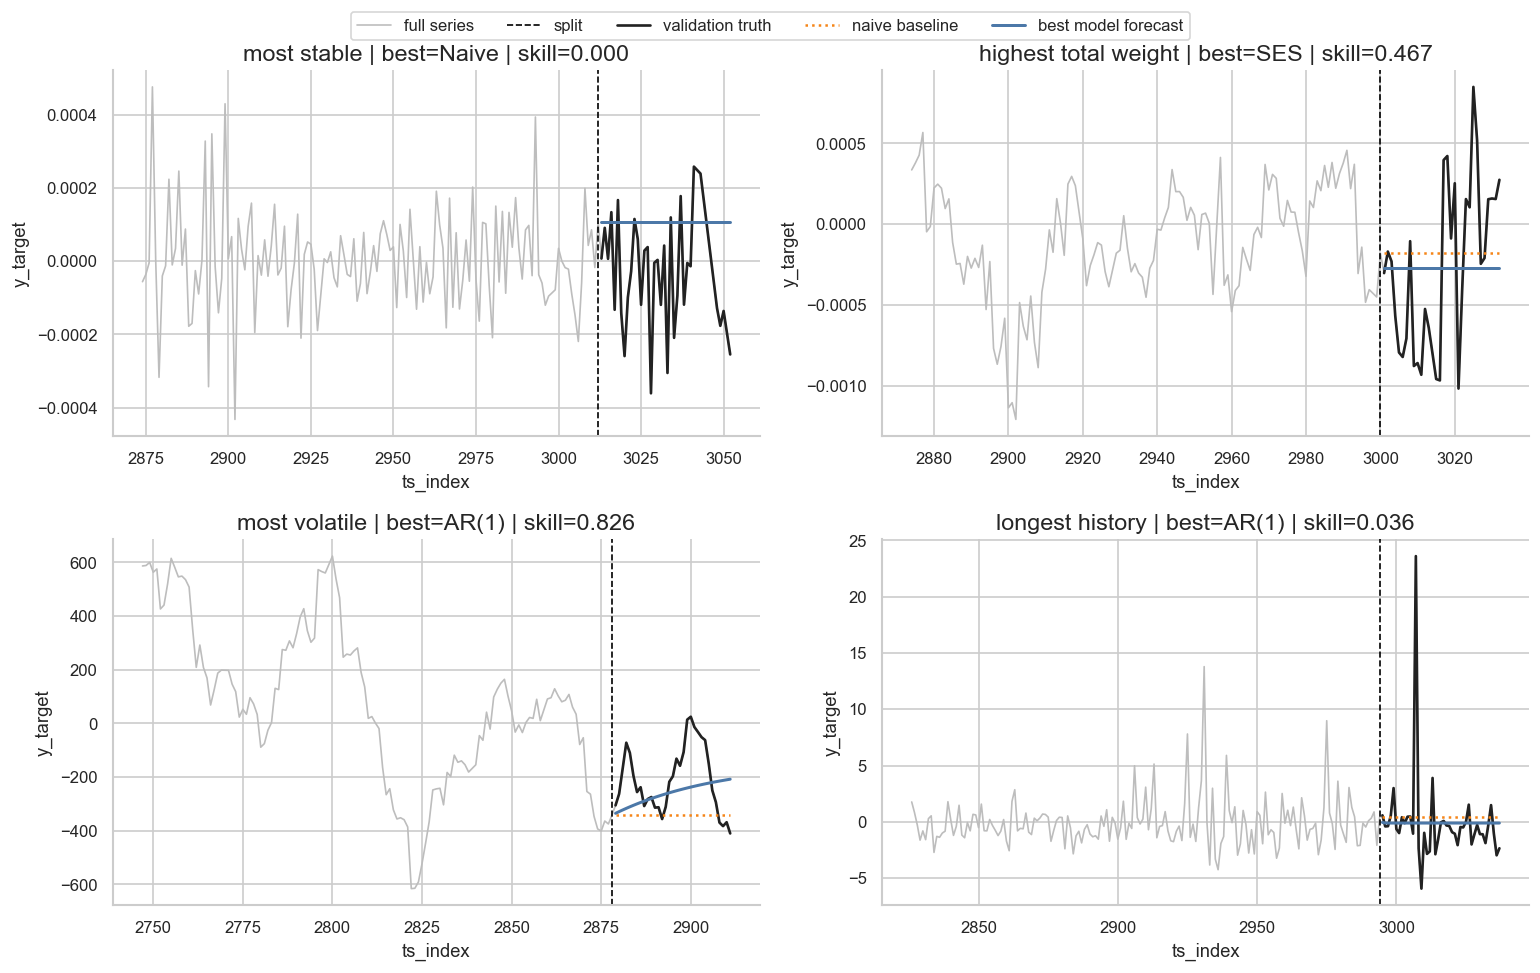

In [6]:
rep_best = best_by_series[best_by_series['role'] == 'representative'].copy()
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=False)
axes = axes.flatten()

for ax, (_, row) in zip(axes, rep_best.iterrows()):
    full_series = series_frames[row['series_id']].sort_values('ts_index').reset_index(drop=True)
    train_part, val_part, info = chronological_split_df(full_series[['ts_index', 'y_target', 'weight']])
    naive_pred = forecasts[(forecasts['series_id'] == row['series_id']) & (forecasts['model'] == 'Naive')]
    best_pred = forecasts[(forecasts['series_id'] == row['series_id']) & (forecasts['model'] == row['model'])]

    ax.plot(full_series['ts_index'], full_series['y_target'], color='#bdbdbd', linewidth=1.0, label='full series')
    ax.axvline(train_part['ts_index'].iloc[-1], color='black', linestyle='--', linewidth=1, label='split')
    ax.plot(val_part['ts_index'], val_part['y_target'], color='#222222', linewidth=1.6, label='validation truth')
    ax.plot(naive_pred['ts_index'], naive_pred['y_pred'], color='#F58518', linestyle=':', linewidth=1.5, label='naive baseline')
    ax.plot(best_pred['ts_index'], best_pred['y_pred'], color='#4C78A8', linewidth=1.8, label='best model forecast')
    ax.set_title(f"{row['label']} | best={row['model']} | skill={row['skill_score']:.3f}")
    ax.set_xlabel('ts_index')
    ax.set_ylabel('y_target')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=5, bbox_to_anchor=(0.5, 1.02))
fig.tight_layout()
export_figure(fig, '02_classical_forecasts.png')
plt.show()


## 3. Broader benchmark

The broader benchmark is small on purpose, but it tests whether the representative story is too anecdotal.

**Final deck figure:** `02_classical_benchmark_skill.png`


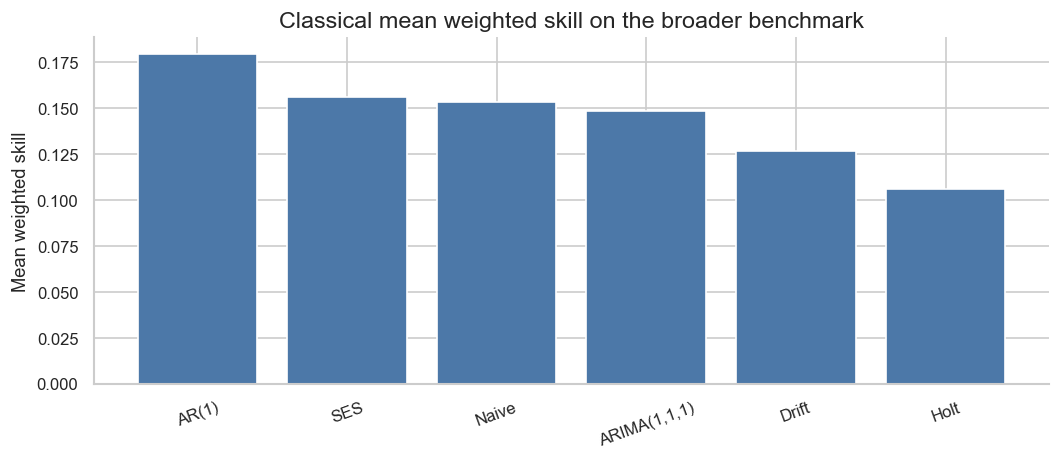

,model,mean_skill,median_skill,mean_rmse
0,AR(1),0.179667,0.039612,0.841265
1,SES,0.156101,0.036956,1.047581
2,Naive,0.153569,0.000000,1.052259
3,"ARIMA(1,1,1)",0.148558,0.000000,1.062414
4,Drift,0.126648,0.000000,1.347971
5,Holt,0.106153,0.000000,1.364483


In [7]:
benchmark_summary = (
    ok_results[ok_results['role'] == 'benchmark']
    .groupby('model')
    .agg(
        mean_skill=('skill_score', 'mean'),
        median_skill=('skill_score', 'median'),
        mean_rmse=('rmse', 'mean'),
    )
    .sort_values('mean_skill', ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(benchmark_summary['model'], benchmark_summary['mean_skill'], color='#4C78A8')
ax.set_title('Classical mean weighted skill on the broader benchmark')
ax.set_ylabel('Mean weighted skill')
ax.tick_params(axis='x', rotation=20)
fig.tight_layout()
export_figure(fig, '02_classical_benchmark_skill.png')
plt.show()

benchmark_summary


## 4. What we learned

- the shared split rule makes the classical study directly comparable to the deep study
- simple baselines still matter
- some series reward smoothing, while others need a more structured model
- the small broader benchmark gives us a more stable reading than 4 examples alone

## What this changes next

`03_deep.ipynb` will keep the same split rule and benchmark, then test target-history recurrent models on the same study set.
